In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

import scipy.stats as stats
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

1. Data Processing

In [2]:
data_path = '/Users/june/Documents/data/tabular_process_param/secom.csv'

# Load in the data
with open (data_path, 'rb') as f:
    data = pd.read_csv(f)

data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [3]:
# Handle missing value
y = data.iloc[:, -1]
X = data.iloc[:, 1:-1]

pipeline = make_pipeline(SimpleImputer(), RandomForestClassifier(n_estimators=100))
imputation_strategies = ['mean','median','most_frequent']

for strategy in imputation_strategies:
    pipeline.set_params(simpleimputer__strategy=strategy)
    scores = cross_val_score(pipeline, X, y, cv=5)  # Perform cross-validation
    print(f"Imputation strategy: {strategy}, Accuracy: {scores.mean()}")
    

Imputation strategy: mean, Accuracy: 0.9253515394477118
Imputation strategy: median, Accuracy: 0.9234407114222339
Imputation strategy: most_frequent, Accuracy: 0.9298081032132028


In [4]:
# fill Nan values with the median of the column
X = X.fillna(X.median())
# get statistics from the data - mean, std, min, max, etc.
X.describe()


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
count,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.0,1567.000000,1567.000000,1567.000000,1567.000000,...,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000
mean,3014.441551,2495.866110,2200.551958,1395.383474,4.171281,100.0,101.116476,0.121825,1.462860,-0.000842,...,0.004974,82.403069,0.500096,0.015317,0.003846,3.067628,0.021458,0.016474,0.005283,99.652345
std,73.480841,80.228143,29.380973,439.837330,56.103721,0.0,6.209385,0.008936,0.073849,0.015107,...,0.001985,56.348694,0.003403,0.017174,0.003719,3.576899,0.012354,0.008805,0.002866,93.864558
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.001000,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000
25%,2966.665000,2452.885000,2181.099950,1083.885800,1.017700,100.0,97.937800,0.121100,1.411250,-0.010800,...,0.004700,72.288900,0.497900,0.011600,0.003100,2.306500,0.013450,0.010600,0.003300,44.368600
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,0.004700,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500
75%,3056.540000,2538.745000,2218.055500,1590.169900,1.518800,100.0,104.530000,0.123800,1.516850,0.008400,...,0.004700,72.288900,0.502350,0.016500,0.004100,3.294950,0.027600,0.020300,0.006400,114.749700
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,0.028600,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800


2. Exploratory Data Analysis

In [24]:
# Remove low variance features
selector = VarianceThreshold(threshold=0.01)  # Adjust based on dataset
X_reduced = selector.fit_transform(X)
# Mutual information for feature selection
mi_scores = mutual_info_classif(X, y, discrete_features=False)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Keep top N most informative features
top_features = mi_scores.head(25).index  # Adjust '50' based on dataset
X_selected = X[top_features]

In [6]:
X_selected.head()

,577,477,541,583,406,128,41,506,428,570,...,413,56,448,172,310,174,37,411,574,6
0,14.9509,5.8142,11.5074,0.0118,14.2396,3.188,4.515,0.0,3.2750,533.8500,...,29.0271,0.9317,0.1362,0.3183,0.3670,0.3184,66.3141,2.1118,3.0624,97.6133
1,10.9003,5.8042,9.5796,0.0223,10.5837,3.272,2.773,0.0,2.8088,535.0164,...,27.7464,0.9324,0.2751,0.4115,0.3752,0.4115,64.9193,2.5197,2.0111,102.3433
2,9.2721,9.1221,9.3046,0.0157,11.4871,3.272,5.434,0.0,3.7479,535.0245,...,21.6062,0.9139,0.2748,0.3141,0.3677,0.3141,65.8389,2.0627,4.0923,95.4878
3,8.5831,6.4746,7.7754,0.0103,13.3972,3.119,1.279,0.0,2.8049,530.5682,...,14.5054,0.9139,0.3332,0.2618,0.3465,0.2618,65.1951,2.1737,2.8971,104.2367
4,10.9698,6.1979,9.4805,0.4766,7.1493,3.299,2.209,0.0,3.4473,532.0155,...,24.4142,0.9298,0.7592,0.3053,0.3072,0.3053,66.1542,2.1850,3.1776,100.3967


In [7]:
# save out the dataset with the selected features with combining them with y
X_selected['Pass/Fail'] = y
X_selected['Time'] = data['Time']
X_selected.to_csv('selected_features.csv', index=False)


/var/folders/xs/5688kgc54c12jm1b6pjmrldr0000gn/T/ipykernel_26699/4127736748.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected['Pass/Fail'] = y
/var/folders/xs/5688kgc54c12jm1b6pjmrldr0000gn/T/ipykernel_26699/4127736748.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected['Time'] = data['Time']


In [8]:
X_selected

,577,477,541,583,406,128,41,506,428,570,...,448,172,310,174,37,411,574,6,Pass/Fail,Time
0,14.9509,5.8142,11.5074,0.0118,14.2396,3.188,4.515,0.0,3.2750,533.8500,...,0.1362,0.3183,0.3670,0.3184,66.3141,2.1118,3.0624,97.6133,-1,2008-07-19 11:55:00
1,10.9003,5.8042,9.5796,0.0223,10.5837,3.272,2.773,0.0,2.8088,535.0164,...,0.2751,0.4115,0.3752,0.4115,64.9193,2.5197,2.0111,102.3433,-1,2008-07-19 12:32:00
2,9.2721,9.1221,9.3046,0.0157,11.4871,3.272,5.434,0.0,3.7479,535.0245,...,0.2748,0.3141,0.3677,0.3141,65.8389,2.0627,4.0923,95.4878,1,2008-07-19 13:17:00
3,8.5831,6.4746,7.7754,0.0103,13.3972,3.119,1.279,0.0,2.8049,530.5682,...,0.3332,0.2618,0.3465,0.2618,65.1951,2.1737,2.8971,104.2367,-1,2008-07-19 14:43:00
4,10.9698,6.1979,9.4805,0.4766,7.1493,3.299,2.209,0.0,3.4473,532.0155,...,0.7592,0.3053,0.3072,0.3053,66.1542,2.1850,3.1776,100.3967,-1,2008-07-19 15:22:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,11.7256,4.4358,8.0758,0.0143,4.3682,3.135,1.427,0.0,1.8345,536.3418,...,0.1319,0.3017,0.2561,0.3017,66.2013,1.4864,2.6401,82.2467,-1,2008-10-16 15:13:00
1563,17.8379,6.5896,10.5805,0.0131,7.6319,3.805,2.945,0.0,2.2577,537.9264,...,0.3443,0.4711,0.2686,0.4711,66.1488,2.6927,1.9077,98.4689,-1,2008-10-16 20:49:00
1564,17.7267,3.4878,9.4593,0.0153,5.9201,3.195,2.863,0.0,2.3283,530.3709,...,0.6701,0.3852,0.3302,0.3852,65.8936,3.3268,2.1760,99.4122,-1,2008-10-17 05:26:00
1565,19.2104,7.6907,10.6207,0.0178,6.1760,3.381,2.067,0.0,1.9365,534.3936,...,0.2279,0.2877,0.2679,0.2877,66.2301,2.9214,3.2524,98.7978,-1,2008-10-17 06:01:00


/var/folders/xs/5688kgc54c12jm1b6pjmrldr0000gn/T/ipykernel_26699/2009838290.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


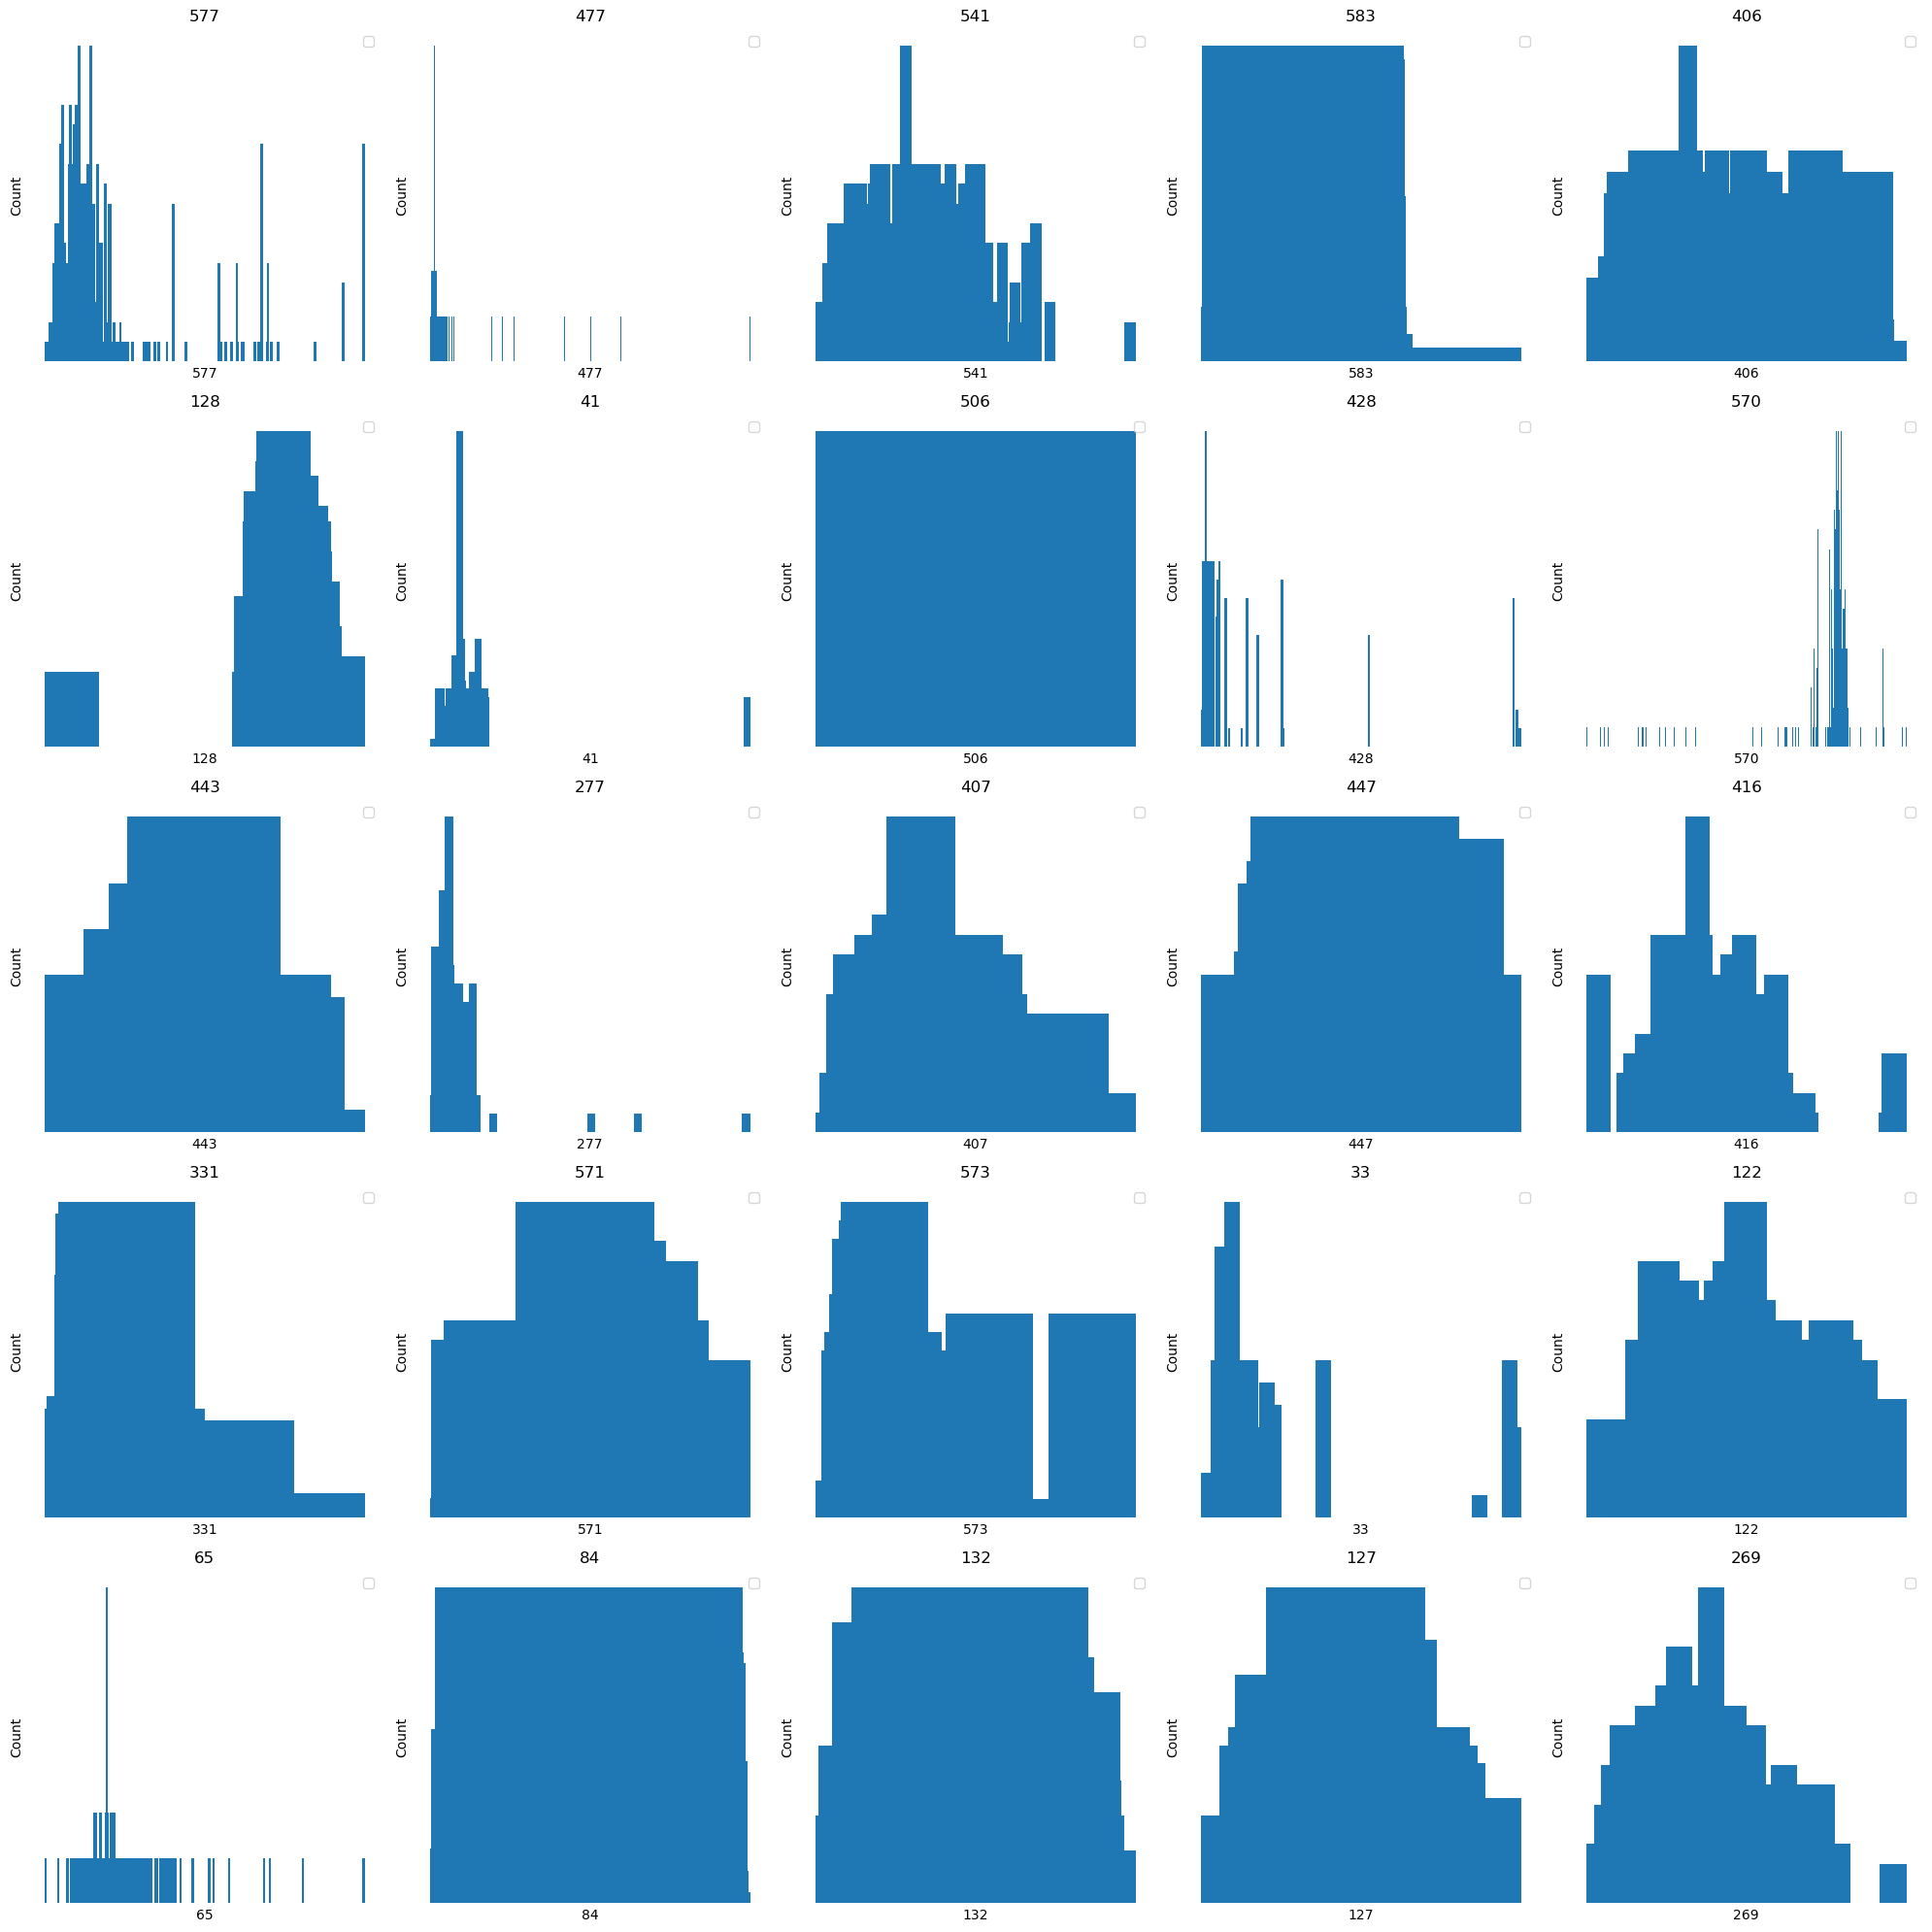

In [23]:
import matplotlib.pyplot as plt

# Plot bar plots for selected features
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for i, ax in enumerate(axes.flatten()):
    if i < X_selected.shape[1]:
        feature_values = X_selected.iloc[:, i].value_counts()
        ax.bar(feature_values.index, feature_values.values)
        ax.set_title(X_selected.columns[i])
        ax.set_xlabel(X_selected.columns[i])
        ax.set_ylabel('Count')
        ax.grid(True)
        ax.legend()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(left=False, bottom=False)
        ax.set_facecolor('white')

plt.tight_layout()
plt.show()

In [18]:
type(X_selected)

pandas.core.frame.DataFrame

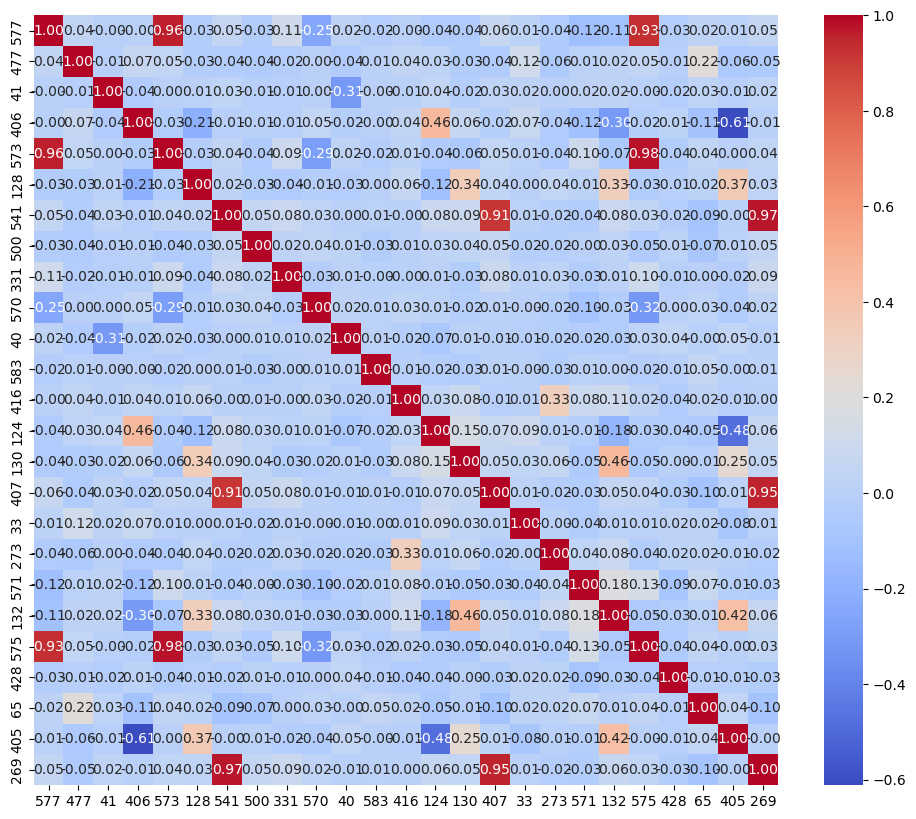

In [26]:
# correlation plot
import seaborn as sns

corr = X_selected.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Choose pair that has a correlation threshold above 0.7
plt.figure(figsize=(12, 10))
corr = X_selected.corr()
threshold = 0.7
high_corr = (corr > threshold) | (corr < -threshold)
# Extract the pair that has high corr and plot 2




